In [13]:
# Import Google Drive module to access files in Colab
from google.colab import drive

# Mount Google Drive to the Colab environment
drive.mount('/content/drive')

# Path to the project dataset stored in Google Drive
DATA_PATH = "/content/drive/MyDrive/photoaging_project/data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Import TensorFlow for building and training the model
import tensorflow as tf

# Define image size and batch size for dataset loading
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset from directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load test dataset (shuffle disabled for evaluation)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Print the class labels detected in the dataset
print(train_ds.class_names)

Found 2130 files belonging to 2 classes.
Found 428 files belonging to 2 classes.
Found 429 files belonging to 2 classes.
['negative', 'positive']


In [15]:
# Enable automatic performance optimization for data loading
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch data to improve training efficiency
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [16]:
# Data augmentation to increase training data variability
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Load MobileNetV2 pretrained on ImageNet without the classification head
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model layers to retain pretrained features
base_model.trainable = False

# Define model input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Apply augmentation and preprocessing
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Extract features using the pretrained base model
x = base_model(x, training=False)

# Reduce feature maps and add regularization
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Output layer for binary classification
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

# Build the final model
model = tf.keras.Model(inputs, outputs)

# Compile the model with optimizer, loss function, and evaluation metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# Train the model using the training dataset and validate with the validation dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.5881 - loss: 0.6900 - val_accuracy: 0.8528 - val_loss: 0.3894
Epoch 2/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.8414 - loss: 0.4024 - val_accuracy: 0.9533 - val_loss: 0.2468
Epoch 3/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9239 - loss: 0.2743 - val_accuracy: 0.9696 - val_loss: 0.1756
Epoch 4/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9455 - loss: 0.2134 - val_accuracy: 0.9766 - val_loss: 0.1380
Epoch 5/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.9491 - loss: 0.1818 - val_accuracy: 0.9813 - val_loss: 0.1119
Epoch 6/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.9646 - loss: 0.1485 - val_accuracy: 0.9836 - val_loss: 0.0953
Epoch 7/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.9763 - loss: 0.1182 - val_accuracy: 0.9836 - val_loss: 0.0846
Epoch 8/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.9719 - loss: 0.1101 - val_accuracy: 0.

In [18]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(test_ds)

# Print the final test accuracy
print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9931 - loss: 0.0895
Test Accuracy: 0.997668981552124


In [19]:
# Import and mount Google Drive to store the trained model
from google.colab import drive
drive.mount('/content/drive')

# Save the trained model to Google Drive
model.save("/content/drive/MyDrive/photoaging_project/photoaging_model_v1.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Import evaluation metrics and NumPy
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Lists to store true labels and predicted labels
y_true = []
y_pred = []

# Generate predictions for the test dataset
for images, labels in test_ds:
    preds = model.predict(images)              # Model predictions
    preds = (preds > 0.5).astype(int)          # Convert probabilities to binary labels

    y_true.extend(labels.numpy())              # Store true labels
    y_pred.extend(preds.flatten())             # Store predicted labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Print classification performance metrics
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[213   1]
 [  0 215]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       214
           1       1.00      1.00      1.00       215

    accuracy                           1.00       429
   macro avg       1.00      1.00      1.00       429
weighted avg       1.00      1.00      1.00       429



In [21]:
# Iterate through layers of the MobileNetV2 base model
for layer in model.get_layer("mobilenetv2_1.00_224").layers:

    # Print the names of all convolutional layers
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)

Conv1
expanded_conv_project
block_1_expand
block_1_project
block_2_expand
block_2_project
block_3_expand
block_3_project
block_4_expand
block_4_project
block_5_expand
block_5_project
block_6_expand
block_6_project
block_7_expand
block_7_project
block_8_expand
block_8_project
block_9_expand
block_9_project
block_10_expand
block_10_project
block_11_expand
block_11_project
block_12_expand
block_12_project
block_13_expand
block_13_project
block_14_expand
block_14_project
block_15_expand
block_15_project
block_16_expand
block_16_project
Conv_1


In [22]:
# Import required libraries for Grad CAM visualization
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Function to generate a Grad CAM heatmap for a given image
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Access the MobileNetV2 base model inside the full model
    base_model = model.get_layer("mobilenetv2_1.00_224")

    # Create a model that outputs the selected convolution layer and predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Record gradients for the predicted class
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    # Compute gradients of the output with respect to feature maps
    grads = tape.gradient(loss, conv_outputs)

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the convolutional feature maps by the gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap values between 0 and 1
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()

Positive Test Image


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_502']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


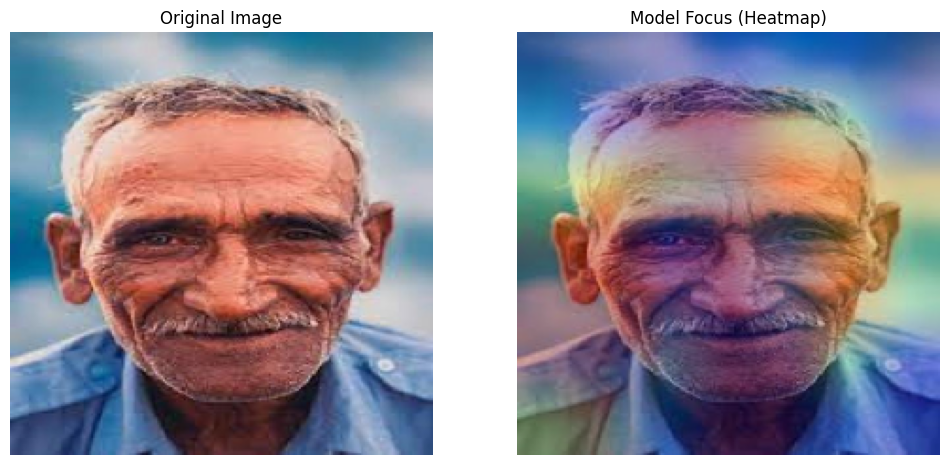

Negative Test Image


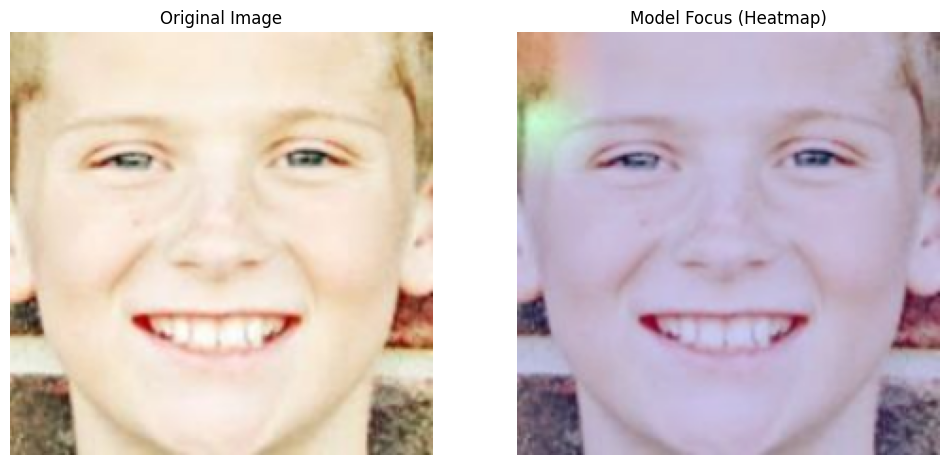

In [29]:
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. Manually preprocess to match MobileNetV2 requirements
    x = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # 2. Get the specific sub-models
    # We navigate: Global Model -> MobileNetV2 -> Target Layer
    base_model = model.get_layer('mobilenetv2_1.00_224')

    # 3. Create a sub-model strictly for the MobileNet features
    # This avoids the 'Sequential' and 'Augmentation' layers that cause the KeyError
    feature_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )

    # 4. Record the operations to calculate gradients
    with tf.GradientTape() as tape:
        # Get conv outputs from the feature extractor
        conv_outputs = feature_extractor(x)
        tape.watch(conv_outputs)

        # Manually complete the rest of the forward pass
        # GlobalAveragePooling -> Dropout -> Dense
        pooling_out = tf.keras.layers.GlobalAveragePooling2D()(conv_outputs)

        # We grab the weights directly from your trained Dense layer
        dense_layer = model.get_layer('dense_1')
        logits = tf.matmul(pooling_out, dense_layer.kernel) + dense_layer.bias

        # Target the specific class score
        loss = logits[:, 0]

    # 5. Extract gradients of the loss w.r.t. the conv layer output
    grads = tape.gradient(loss, conv_outputs)

    # 6. Compute heatmap math
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Final normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Model Focus (Heatmap)")
    plt.axis("off")
    plt.show()

# --- RUN GRAD-CAM ---
# Use one of your positive test images
sample_path = "/content/drive/MyDrive/photoaging_project/data/test/positive/99_jpg.rf.560e3437ad8b16689479d0f4707e44e3.jpg"
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Positive Test Image")
heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
display_gradcam(sample_path, heatmap)


sample_path = "/content/drive/MyDrive/photoaging_project/data/test/negative/10_0_0_20170110220557169.jpg.chip.jpg"
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Negative Test Image")
heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
display_gradcam(sample_path, heatmap)

In [33]:
# -----------------------------------------
# LOAD AIR POLLUTION DATASET
# -----------------------------------------

import pandas as pd

AQI_PATH = "/content/drive/MyDrive/photoaging_project/AQI and Lat Long of Countries.csv"

aqi_df = pd.read_csv(AQI_PATH)

# Keep only relevant columns
aqi_df = aqi_df[["City","Country","PM2.5 AQI Value"]]

# Rename for simplicity
aqi_df.columns = ["city","country","pm25_aqi"]

# Remove missing values
aqi_df = aqi_df.dropna()

# Convert to lowercase for easier matching
aqi_df["city"] = aqi_df["city"].str.lower()
aqi_df["country"] = aqi_df["country"].str.lower()

# Average duplicate monitoring stations
aqi_df = aqi_df.groupby(["city","country"], as_index=False).mean()

print("Pollution dataset loaded.")
print("Total cities:", len(aqi_df))

Pollution dataset loaded.
Total cities: 13956


In [37]:
import difflib

def get_city_pm25(city_name):

    city_name = city_name.strip().lower()

    # Find matches
    matches = aqi_df[aqi_df["city"] == city_name]

    if len(matches) == 1:
        return float(matches.iloc[0]["pm25_aqi"])

    if len(matches) > 1:
        print("\nMultiple cities found with that name:")

        for i, row in matches.iterrows():
            print(f"{i}: {row['city'].title()}, {row['country'].title()}")

        selection = int(input("Select the correct city number: "))
        return float(aqi_df.loc[selection]["pm25_aqi"])

    # If city not found → suggest closest cities
    print("\nCity not found.")

    suggestions = difflib.get_close_matches(city_name, aqi_df["city"].unique(), n=5)

    if suggestions:
        print("Did you mean one of these?")
        for s in suggestions:
            print("-", s.title())

    return None

    # -----------------------------------------
# CONVERT AQI TO POLLUTION RISK SCORE
# -----------------------------------------

def normalize_pm25_aqi(aqi):

    if aqi is None:
        return 0.6

    if aqi <= 50:
        return 0.2

    elif aqi <= 100:
        return 0.4

    elif aqi <= 150:
        return 0.6

    elif aqi <= 200:
        return 0.8

    else:
        return 1.0

In [38]:
# ============================================================
# PHOTOAGING BURDEN INDEX (PBI)
# Combines CNN visible photoaging prediction with lifestyle exposure factors
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from PIL import Image
import io

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

MODEL_PATH = "/content/drive/MyDrive/photoaging_project/photoaging_model_v1.keras"
model = tf.keras.models.load_model(MODEL_PATH)

IMG_SIZE = (224, 224)
BASE_MODEL_NAME = "mobilenetv2_1.00_224"
LAST_CONV_LAYER_NAME = "Conv_1"

# ------------------------------------------------------------
# IMAGE UPLOAD
# ------------------------------------------------------------

print("\nUpload a clear frontal face image.")
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
img_pil = Image.open(io.BytesIO(uploaded[image_name])).convert("RGB")
img_resized = img_pil.resize(IMG_SIZE)

img_array = np.array(img_resized).astype(np.float32)
img_array = np.expand_dims(img_array, axis=0)

# ------------------------------------------------------------
# CNN VISIBLE PHOTOAGING SCORE
# ------------------------------------------------------------

x_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
prediction = model.predict(x_preprocessed, verbose=0)
P_vis = float(prediction[0, 0])

# ------------------------------------------------------------
# LIFESTYLE QUESTIONNAIRE
# ------------------------------------------------------------

print("\n=== Lifestyle Questionnaire ===")

hours_outdoors = float(
    input("How many hours do you on average spend outdoors per day? (0–8): ")
)

cigs_per_day = int(
    input("Do you smoke cigarettes? If yes, how many per day? (0 if none): ")
)

# --- Pollution input with validation ---
pm25_value = None

while pm25_value is None:

    city = input("Which city do you live in most of the time? ")
    pm25_value = get_city_pm25(city)

sunscreen_use = input(
    "Do you apply sunscreen daily? (yes/no): "
).strip().lower()

# ------------------------------------------------------------
# NORMALIZATION FUNCTIONS
# ------------------------------------------------------------

def clamp01(x):
    return float(max(0.0, min(1.0, x)))

# UV exposure proxy
U = clamp01(hours_outdoors / 6.0)

# Smoking exposure proxy
S = clamp01(cigs_per_day / 20.0)

# Pollution exposure using AQI dataset
P = normalize_pm25_aqi(pm25_value)

print("\nPollution Data:")
print("City PM2.5 AQI:", pm25_value)
print("Pollution Risk Score:", round(P, 3))

# Sunscreen protection modifier
C_protection = {"yes": 1.0, "no": 0.0}.get(sunscreen_use, 0.0)

# ------------------------------------------------------------
# EXPOSURE RISK SCORE
# ------------------------------------------------------------

W_UV = 0.70
W_SMOKE = 0.15
W_POLL = 0.10
W_SUNSCREEN = 0.05

R_exp = (
    W_UV * U +
    W_SMOKE * S +
    W_POLL * P +
    W_SUNSCREEN * (1 - C_protection)
)

R_exp = clamp01(R_exp)

# ------------------------------------------------------------
# FINAL PHOTOAGING BURDEN INDEX
# ------------------------------------------------------------

ALPHA = 0.80

PBI = clamp01(
    ALPHA * P_vis +
    (1 - ALPHA) * R_exp
)

# ------------------------------------------------------------
# CATEGORY INTERPRETATION
# ------------------------------------------------------------

def category(score):

    if score < 0.33:
        return "Low"

    elif score < 0.66:
        return "Moderate"

    else:
        return "High"

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n=== Photoaging Burden Results ===")

print("Visible Photoaging Probability:", round(P_vis, 4))
print("Exposure Risk Component:", round(R_exp, 4))
print("Final Photoaging Burden Index:", round(PBI, 4))
print("Severity Category:", category(PBI))

print("\nNormalized Factors:")
print("UV:", round(U, 3))
print("Smoking:", round(S, 3))
print("Pollution:", round(P, 3))
print("Sunscreen Protection:", round(C_protection, 3))


Upload a clear frontal face image.


Saving MyImage.jpg to MyImage (3).jpg



=== Lifestyle Questionnaire ===
How many hours do you on average spend outdoors per day? (0–8): 1
Do you smoke cigarettes? If yes, how many per day? (0 if none): 2
Which city do you live in most of the time? London
Do you apply sunscreen daily? (yes/no): yes

Pollution Data:
City PM2.5 AQI: 40.0
Pollution Risk Score: 0.2

=== Photoaging Burden Results ===
Visible Photoaging Probability: 0.3341
Exposure Risk Component: 0.1517
Final Photoaging Burden Index: 0.2976
Severity Category: Low

Normalized Factors:
UV: 0.167
Smoking: 0.1
Pollution: 0.2
Sunscreen Protection: 1.0
